-----
# **Multi-Model Spam Detection & Sentiment Analysis**
------
###  _Benchmarking Classical ML, Deep Learning, and Transformers on Imbalanced Text Data_

#### **Author** : HASFA ROUCHDI
#### **Medium**: https://medium.com/@h.rouchdi6
#### **Kaggle**: https://www.kaggle.com/hafsarouchdi

-----

## **Project Overview**

Email and SMS spam remains one of the most persistent problems in digital communication. This notebook addresses it through a **two-phase pipeline**.

**Phase 1 : Spam Classification:** Eight models benchmarked across three paradigms:
- *Classical ML:* Logistic Regression, SVM, Random Forest, XGBoost (TF-IDF + GridSearchCV)
- *Deep Learning:* LSTM, BiLSTM (embedding + recurrent layers)
- *Transformers:* BERT, GPT-2 (fine-tuned on SMOTE-balanced data)

All models share the same 80/20 split of the [UCI SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) (5,572 messages; ~87% ham, ~13% spam). Given the class imbalance, models are compared on **F1-score**, **PR-AUC**, and **ROC-AUC** rather than raw accuracy.

**Phase 2 : Sentiment Enrichment:** The best classifier (BiLSTM) is paired with VADER to annotate every message with a spam label and a positive/neutral/negative sentiment score.

**Tech stack:** Python · scikit-learn · TensorFlow/Keras · PyTorch · HuggingFace Transformers · VADER · imbalanced-learn (SMOTE)

## Installation

Install non-standard dependencies. On Kaggle, `scikit-learn==1.2.2` is pinned to match the runtime; adjust the version if running locally.

In [1]:
!pip install -U scikit-learn vaderSentiment --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 16.1 MB/s eta 0:00:00


## Importing Libraries

In [2]:
# Standard library
import os
import re
import string
from collections import Counter

# Data manipulation & visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report, confusion_matrix,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# HuggingFace Transformers  (PyTorch backend for both BERT and GPT-2)
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    GPT2Tokenizer, GPT2ForSequenceClassification
)

# PyTorch
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

# NLP / Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Networking (manual model weight download)
import requests


## 1. Data Loading

In [3]:
from google.colab import files
import io

# Upload spam.csv when prompted
# Download the dataset from: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
uploaded = files.upload()  # select spam.csv from your local machine

filename = list(uploaded.keys())[0]
data = pd.read_csv(io.BytesIO(uploaded[filename]), encoding="latin-1")
data = data.rename(columns={"v1": "label", "v2": "text"})
data = data[["label", "text"]]
data["label"] = data["label"].map({"ham": 0, "spam": 1})

print(f"Dataset loaded: {data.shape[0]:,} messages")
data.head()

Saving spam_dataset.csv to spam_dataset.csv
Dataset loaded: 5,572 messages


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 2. Dataset Overview

In [4]:
print("=" * 45)
print(f"Shape         : {data.shape}")
print(f"Columns       : {list(data.columns)}")
print(f"Missing values: {data.isnull().sum().sum()}")
print("Class distribution:")
counts = data['label'].value_counts().rename({0: 'ham', 1: 'spam'})
for label, n in counts.items():
    print(f"  {label}: {n} ({n/len(data)*100:.1f}%)")
print("=" * 45)
data.describe()

Shape         : (5572, 2)
Columns       : ['label', 'text']
Missing values: 0
Class distribution:
  ham: 4825 (86.6%)
  spam: 747 (13.4%)


,label
count,5572.000000
mean,0.134063
std,0.340751
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [5]:
data.isnull().sum()

,0
label,0
text,0


## 3. Data Preprocessing

The `clean_text()` function normalises each message before feature extraction: it lowercases text, strips punctuation and digits, and collapses extra whitespace.

Stopwords are intentionally retained terms like *free*, *you*, and *now* carry meaningful signal for spam classifiers.

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)  # Remove punctuation
    text = re.sub(r"\d+", "", text)  # Remove numbers
    text = re.sub(r"\s+", " ", text)  # Remove extra whitespace
    return text

data["clean_text"] = data["text"].apply(clean_text)

## 4. Exploratory Data Analysis

### 4.1 Word Cloud — Spam vs Ham

Word clouds compare the most frequent terms in spam versus ham messages. Spam vocabulary clusters around urgency and reward (free, win, call now), while ham messages reflect everyday conversational language.

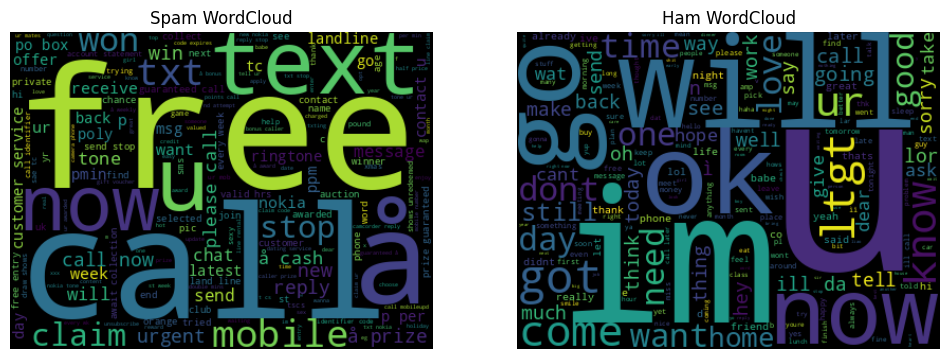

In [7]:
spam_text = " ".join(data[data["label"] == 1]["clean_text"])
ham_text = " ".join(data[data["label"] == 0]["clean_text"])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Spam WordCloud")
spam_wc = WordCloud(width=400, height=300, background_color="black").generate(spam_text)
plt.imshow(spam_wc, interpolation="bilinear")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Ham WordCloud")
ham_wc = WordCloud(width=400, height=300, background_color="black").generate(ham_text)
plt.imshow(ham_wc, interpolation="bilinear")
plt.axis("off")
plt.show()

### 4.2 Class Distribution

The dataset is heavily imbalanced (~87% ham, ~13% spam). This motivates SMOTE before transformer training and the choice of F1-score as the primary evaluation metric.

/tmp/ipykernel_2799/219138293.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="label", data=data, palette="viridis")


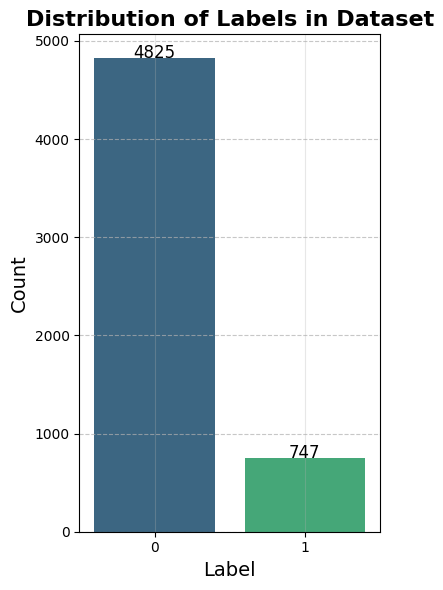

In [8]:
plt.figure(figsize=(4, 6))
ax = sns.countplot(x="label", data=data, palette="viridis")

for p in ax.patches:

    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.1,
        f'{int(height)}',
        ha="center",
        fontsize=12,
        color='black'
    )

plt.title('Distribution of Labels in Dataset',fontweight='bold', fontsize=16)
plt.xlabel('Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle='-', alpha=0.3)

plt.tight_layout()

plt.show()

In [9]:
X = data["clean_text"]
y = data["label"]
print('Original dataset shape', Counter(y))

Original dataset shape Counter({0: 4825, 1: 747})


## 5. Train-Test Split

In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["clean_text"], data["label"], test_size=0.2, random_state=42)

## 6. Feature Engineering: Tokenization and Vectorization

Two representations are prepared in parallel:

- **TF-IDF vectors** (`max_features=5000`): used by classical ML models.
- **Integer sequences** (padded to `maxlen=100`): used by LSTM and BiLSTM.


In [11]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train_text)
X_test_vec = tfidf.transform(X_test_text)

text_tokenizer = Tokenizer()
text_tokenizer.fit_on_texts(X_train_text)
X_train_seq = pad_sequences(text_tokenizer.texts_to_sequences(X_train_text), maxlen=100)
X_test_seq = pad_sequences(text_tokenizer.texts_to_sequences(X_test_text), maxlen=100)

---
## Part 1 : Spam Classification
### Classical Machine Learning Models

> All four models use `GridSearchCV` (5-fold CV). **`scoring='f1'`** is used throughout on an 87/13 split, accuracy is misleading (a trivial all-ham classifier scores ~87% while catching zero spam).

#### Evaluation utility

The helper below returns accuracy, precision, recall, and F1 with binary averaging targeting the spam (positive) class.

In [12]:
def get_metrics(y_true, y_pred):
    """Return (accuracy, precision, recall, f1) — binary avg on spam class."""
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average='binary', zero_division=0)
    rec = recall_score(y_true, y_pred, average='binary', zero_division=0)
    f1  = f1_score(y_true, y_pred, average='binary', zero_division=0)
    return acc, pre, rec, f1


### 1.1 Logistic Regression

Logistic Regression is effective for simple linear separations.

In [13]:
lr_params = {"C": [0.01, 0.1, 1, 10], "solver": ["liblinear", "lbfgs"]}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), lr_params, cv=5, scoring="f1")
grid_lr.fit(X_train_vec, y_train)
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_vec)

### 1.2 Support Vector Machine (SVM)

SVM provides strong classification boundaries.

In [14]:
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_model = SVC(probability=True, random_state=42)
grid_svm = GridSearchCV(svm_model, svm_params, cv=5, scoring="f1")
grid_svm.fit(X_train_vec, y_train)
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_vec)

### 1.3 Random Forest

Random Forest offers robustness through ensemble learning.

In [15]:
rf_params = {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 7]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring="f1")
grid_rf.fit(X_train_vec, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_vec)

In [16]:
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
rf_precision = rf_report["weighted avg"]["precision"]
rf_recall = rf_report["weighted avg"]["recall"]
rf_f1_score = rf_report["weighted avg"]["f1-score"]

### 1.4 XGBoost

XGBoost combines gradient boosting with regularization for high predictive accuracy.

In [17]:
xgb_params = {"learning_rate": [0.01, 0.1, 0.2], "max_depth": [3, 5, 7], "n_estimators": [50, 100, 200]}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42), xgb_params, cv=5, scoring="f1")
grid_xgb.fit(X_train_vec, y_train)
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_vec)
y_prob_xgb = best_xgb.predict_proba(X_test_vec)[:, 1]

---
## Deep Learning Models

Deep learning models like LSTM (Long Short-Term Memory) and BiLSTM (Bidirectional LSTM) are powerful tools for spam detection, as they excel at capturing complex patterns and long-range dependencies in sequential text data.

By training on sequential data, LSTM and BiLSTM can achieve high precision and recall, making them highly effective in distinguishing between spam and non-spam content in real-world applications

#### 2.1 LSTM

LSTM processes sequences by maintaining memory cells, enabling it to learn from past information.

In [18]:
vocab_size = len(text_tokenizer.word_index) + 1
embedding_dim = 50

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=100),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

lstm_model.fit(X_train_seq, y_train, epochs=5, batch_size=32, validation_data=(X_test_seq, y_test))
y_pred_lstm = (lstm_model.predict(X_test_seq) > 0.5).astype(int).flatten()

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9336 - loss: 0.1947 - val_accuracy: 0.9803 - val_loss: 0.0783
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9868 - loss: 0.0477 - val_accuracy: 0.9794 - val_loss: 0.0709
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9957 - loss: 0.0171 - val_accuracy: 0.9803 - val_loss: 0.0978
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9980 - loss: 0.0094 - val_accuracy: 0.9821 - val_loss: 0.0921
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9991 - loss: 0.0041 - val_accuracy: 0.9785 - val_loss: 0.0865
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


#### 2.2 BiLSTM

BiLSTM processes text in both forward and backward directions, providing a more comprehensive understanding of the context.

In [19]:
max_words = 5000
max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

bi_lstm_model = Sequential()
bi_lstm_model.add(Embedding(max_words, 128, input_length=max_len))
bi_lstm_model.add(Bidirectional(LSTM(64)))
bi_lstm_model.add(Dense(1, activation='sigmoid'))
bi_lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
bi_lstm_model.fit(X_train_pad, y_train, epochs=3, batch_size=64, validation_data=(X_test_pad, y_test))

y_pred_bilstm = (bi_lstm_model.predict(X_test_pad) > 0.5).astype(int)

Epoch 1/3
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9242 - loss: 0.2245 - val_accuracy: 0.9767 - val_loss: 0.0970
Epoch 2/3
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9874 - loss: 0.0511 - val_accuracy: 0.9848 - val_loss: 0.0599
Epoch 3/3
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9937 - loss: 0.0231 - val_accuracy: 0.9848 - val_loss: 0.0587
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


---
## Balancing Data with SMOTE

SMOTE generates synthetic minority-class (spam) examples in TF-IDF feature space, producing a balanced training set without discarding ham messages. It is applied only before transformer training.

Balancing data using SMOTE (Synthetic Minority Over-sampling Technique) is important before applying transformer models like BERT and GPT-2, as it addresses class imbalance by generating synthetic samples of the minority class. This ensures a more equal representation of both spam and non-spam classes, helping the model learn effectively from both. Balanced data improves model generalization, accuracy, and reduces overfitting, leading to more reliable spam detection.

### Step 1 — TF-IDF Vectorization

In [20]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vectorized = vectorizer.fit_transform(X_train_text).toarray()

### Step 2 — Apply SMOTE

In [21]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_vectorized, y_train)
print("After balancing:", Counter(y_train_balanced))

After balancing: Counter({0: 3860, 1: 3860})


---
### Transformer Models

Large pre-trained transformer models are fine-tuned for spam classification using SMOTE-balanced data. Note: BERT is already bidirectional by design, no 'BERT' prefix is needed; the correct model name is simply **BERT**.

#### 3.1 BERT (bert-base-uncased)

##### 3.1.1 Initialise BERT tokenizer and model

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
).to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##### 3.1.2 Convert SMOTE-balanced vectors back to text

In [23]:
# Reconstruct text from SMOTE-balanced TF-IDF vectors
X_train_text_balanced = [
    " ".join(vectorizer.inverse_transform(x.reshape(1, -1))[0])
    for x in X_train_balanced
]

# Tokenize for BERT (PyTorch tensors)
def bert_tokenize(texts, tokenizer, max_len=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

train_enc = bert_tokenize(X_train_text_balanced, bert_tokenizer)
test_enc  = bert_tokenize(X_test_text.tolist(), bert_tokenizer)

# Build TensorDatasets
from torch.utils.data import TensorDataset
bert_train_dataset = TensorDataset(
    train_enc['input_ids'],
    train_enc['attention_mask'],
    torch.tensor(y_train_balanced.tolist(), dtype=torch.long)
)
bert_test_dataset = TensorDataset(
    test_enc['input_ids'],
    test_enc['attention_mask'],
    torch.tensor(y_test.tolist(), dtype=torch.long)
)

bert_train_loader = DataLoader(bert_train_dataset, batch_size=16, shuffle=True)
bert_test_loader  = DataLoader(bert_test_dataset,  batch_size=16)


##### 3.1.3 Compile and train BERT

In [24]:
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5)
bert_loss_fn   = nn.CrossEntropyLoss()

bert_model.train()
for epoch in range(3):
    total_loss = 0
    for batch in tqdm(bert_train_loader, desc=f"BERT Epoch {epoch+1}/3"):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        bert_optimizer.zero_grad()
        outputs = bert_model(input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        bert_optimizer.step()
        total_loss += outputs.loss.item()
    print(f"Epoch {epoch+1} — Loss: {total_loss/len(bert_train_loader):.4f}")


BERT Epoch 1/3: 100%|██████████| 483/483 [02:06<00:00,  3.83it/s]


Epoch 1 — Loss: 0.0787


BERT Epoch 2/3: 100%|██████████| 483/483 [02:07<00:00,  3.79it/s]


Epoch 2 — Loss: 0.0214


BERT Epoch 3/3: 100%|██████████| 483/483 [02:07<00:00,  3.80it/s]

Epoch 3 — Loss: 0.0068


##### 3.1.4 Generate predictions

In [25]:
bert_model.eval()
y_pred_bibert, y_prob_bibert = [], []

with torch.no_grad():
    for batch in bert_test_loader:
        input_ids, attention_mask, _ = [b.to(device) for b in batch]
        outputs = bert_model(input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        y_prob_bibert.extend(probs[:, 1])
        y_pred_bibert.extend(probs[:, 1].round().astype(int))

y_pred_bibert = np.array(y_pred_bibert)
y_prob_bibert = np.array(y_prob_bibert)


##### 3.1.5 Classification report

In [26]:
report_bert = classification_report(y_test, y_pred_bibert, zero_division=1)
precision_bert = precision_score(y_test, y_pred_bibert, zero_division=1)
recall_bert = recall_score(y_test, y_pred_bibert, zero_division=1)
f1_bert = f1_score(y_test, y_pred_bibert, zero_division=1)
print(report_bert)
print(f"Precision: {precision_bert}")
print(f"Recall: {recall_bert}")
print(f"F1 Score: {f1_bert}")

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       965
           1       0.98      0.95      0.96       150

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115

Precision: 0.9793103448275862
Recall: 0.9466666666666667
F1 Score: 0.9627118644067797


##### 3.1.6 Extract weighted-average metrics

In [27]:
report_bert = classification_report(y_test, y_pred_bibert, output_dict=True, zero_division=1)
bert_precision = report_bert["weighted avg"]["precision"]
bert_recall = report_bert["weighted avg"]["recall"]
bert_f1_score = report_bert["weighted avg"]["f1-score"]
bert_accuracy = report_bert["accuracy"]

In [28]:
print(f"BERT Precision (Weighted Avg): {bert_precision:.4f}")
print(f"BERT Recall (Weighted Avg): {bert_recall:.4f}")
print(f"BERT F1-Score (Weighted Avg): {bert_f1_score:.4f}")
print("BERT Accuracy :",bert_accuracy)

BERT Precision (Weighted Avg): 0.9901
BERT Recall (Weighted Avg): 0.9901
BERT F1-Score (Weighted Avg): 0.9901
BERT Accuracy : 0.9901345291479821


#### 3.2 GPT-2

In [29]:
# All required libraries were imported in the global imports cell.
# GPT-2 data preparation proceeds below.


##### 3.2.1 Load and preprocess data

In [30]:
# Use clean_text (consistent with all other models)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["clean_text"], data["label"], test_size=0.2, random_state=42
)


###### a. TF-IDF vectorization

In [31]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vectorized = vectorizer.fit_transform(X_train_text).toarray()
X_test_vectorized = vectorizer.transform(X_test_text).toarray()

###### b. Apply SMOTE

In [32]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_vectorized, y_train)
print("After balancing:", Counter(y_train_balanced))

After balancing: Counter({0: 3860, 1: 3860})


##### 3.2.2 Load GPT-2 model and tokenizer

In [33]:
model_dir = "/content/gpt2"
os.makedirs(model_dir, exist_ok=True)

files = {
    "config.json": "https://huggingface.co/gpt2/resolve/main/config.json",
    "pytorch_model.bin": "https://huggingface.co/gpt2/resolve/main/pytorch_model.bin",
    "vocab.json": "https://huggingface.co/gpt2/resolve/main/vocab.json",
    "merges.txt": "https://huggingface.co/gpt2/resolve/main/merges.txt",
}

for filename, url in files.items():
    response = requests.get(url)
    with open(os.path.join(model_dir, filename), "wb") as f:
        f.write(response.content)

tokenizer = GPT2Tokenizer.from_pretrained(model_dir)
tokenizer.pad_token = tokenizer.eos_token
model = GPT2ForSequenceClassification.from_pretrained(model_dir, num_labels=2)
model.config.pad_token_id = tokenizer.pad_token_id

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: /content/gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##### 3.2.3 Prepare dataset

###### a. Reconstruct text from TF-IDF vectors

In [34]:
class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        label = self.labels.iloc[idx]

        # Handle empty input
        if not text.strip():
            text = "[PAD]"

        encodings = self.tokenizer(
            text, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt"
        )
        return {
            "input_ids": encodings["input_ids"].squeeze(),
            "attention_mask": encodings["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

In [35]:
train_texts = pd.Series([" ".join(text) for text in vectorizer.inverse_transform(X_train_balanced)])
train_labels = pd.Series(y_train_balanced)
val_texts = pd.Series([" ".join(text) for text in vectorizer.inverse_transform(X_test_vectorized)])
val_labels = pd.Series(y_test)

In [36]:
train_dataset = SpamDataset(train_texts, train_labels, tokenizer, max_len=128)
val_dataset = SpamDataset(val_texts, val_labels, tokenizer, max_len=128)

###### b. DataLoaders

In [37]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

##### 3.2.4 Training setup

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-5)
loss_fn = nn.CrossEntropyLoss()

##### 3.2.5 Training loop

In [39]:
epochs = 3
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch + 1} Training Loss: {train_loss / len(train_loader)}")

Epoch 1/3: 100%|██████████| 483/483 [03:22<00:00,  2.38it/s]


Epoch 1 Training Loss: 0.17416958098673874


Epoch 2/3: 100%|██████████| 483/483 [03:22<00:00,  2.39it/s]


Epoch 2 Training Loss: 0.04552213269404924


Epoch 3/3: 100%|██████████| 483/483 [03:22<00:00,  2.39it/s]

Epoch 3 Training Loss: 0.024742067393648686


##### 3.2.6 Evaluation

In [40]:
model.eval()
val_loss = 0
predictions = []
true_labels = []
y_prob_gpt2 = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        val_loss += outputs.loss.item()

        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(labels.cpu().numpy())

        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        y_prob_gpt2.extend(probs[:, 1])

##### 3.2.7 Save model

In [41]:
model.save_pretrained("/content/gpt2_balanced")
tokenizer.save_pretrained("/content/gpt2_balanced")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/gpt2_balanced/tokenizer_config.json',
 '/content/gpt2_balanced/tokenizer.json')

##### 3.2.8 Classification report

In [42]:
report_gpt = classification_report(true_labels, predictions, zero_division=1)
precision_gpt = precision_score(true_labels, predictions, zero_division=1)
recall_gpt = recall_score(true_labels, predictions, zero_division=1)
f1_gpt = f1_score(true_labels, predictions, zero_division=1)

In [43]:
print(report_gpt)
print(f"Precision: {precision_gpt}")
print(f"Recall: {recall_gpt}")
print(f"F1 Score: {f1_gpt}")

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.90      0.94       150

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115

Precision: 0.9926470588235294
Recall: 0.9
F1 Score: 0.9440559440559441


---
## Results and Visualisation

### 1. Model Performance Comparison

Bar chart comparing all eight models across accuracy, precision, recall, and F1-score. F1-score is the most informative single metric given the class imbalance.

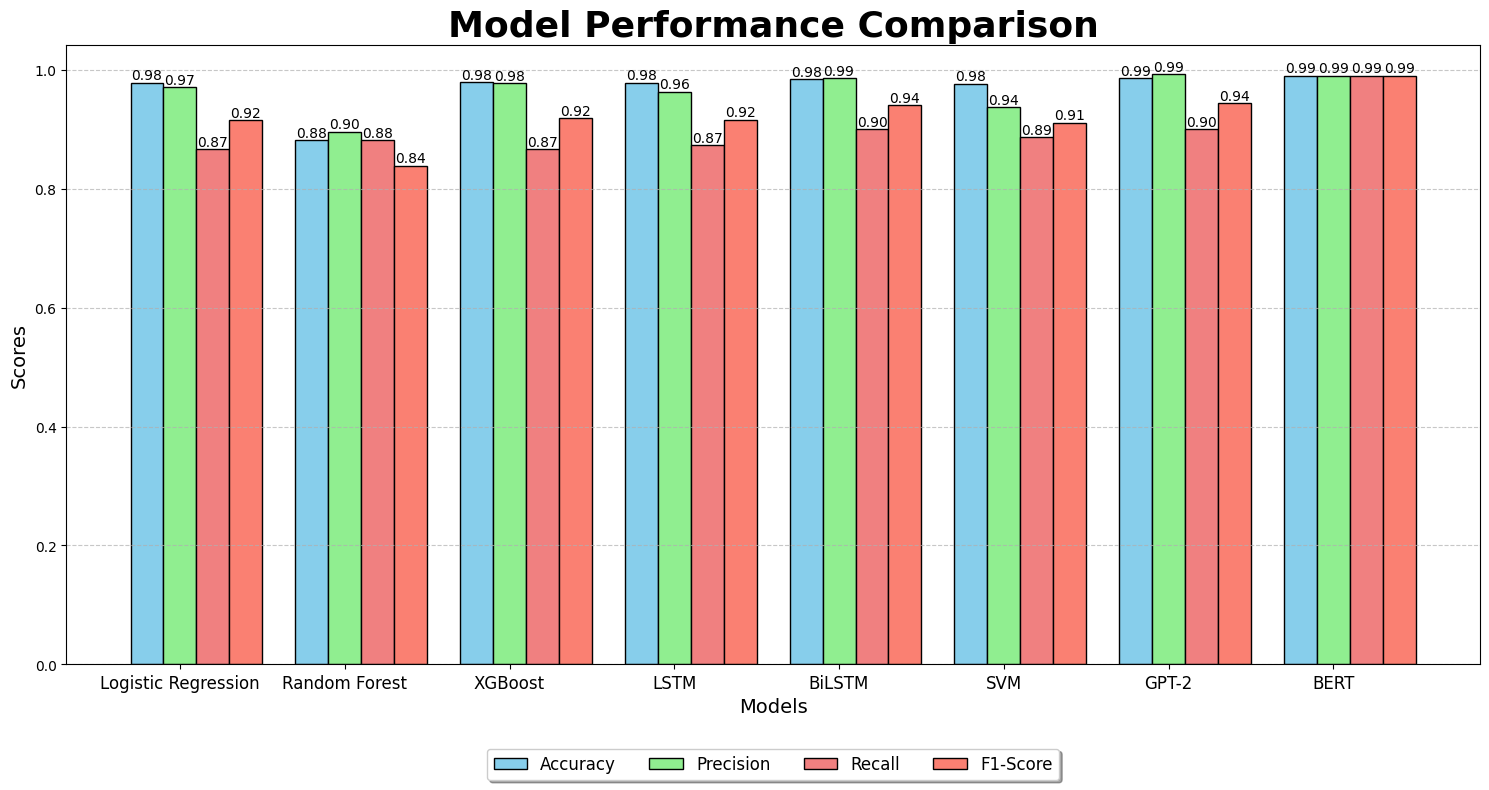

In [44]:
models = ["Logistic Regression", "Random Forest", "XGBoost", "LSTM", "BiLSTM", "SVM", "GPT-2" , "BERT"]

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lstm),
    accuracy_score(y_test, y_pred_bilstm),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(true_labels, predictions),
    accuracy_score(y_test, y_pred_bibert),


]
precisions = [
    precision_score(y_test, y_pred_lr),
    rf_precision,
    precision_score(y_test, y_pred_xgb),
    precision_score(y_test, y_pred_lstm),
    precision_score(y_test, y_pred_bilstm),
    precision_score(y_test, y_pred_svm),
    precision_score(true_labels, predictions),
    bert_precision,

]
recalls = [
    recall_score(y_test, y_pred_lr),
    rf_recall,
    recall_score(y_test, y_pred_xgb),
    recall_score(y_test, y_pred_lstm),
    recall_score(y_test, y_pred_bilstm),
    recall_score(y_test, y_pred_svm),
    recall_score(true_labels, predictions),
    bert_recall,

]
f1_scores = [
    f1_score(y_test, y_pred_lr),
    rf_f1_score,
    f1_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_lstm),
    f1_score(y_test, y_pred_bilstm),
    f1_score(y_test, y_pred_svm),
    f1_score(true_labels, predictions),
    bert_f1_score,

]

plt.figure(figsize=(15, 8))
x = np.arange(len(models))  # the label locations
width = 0.2  # the width of the bars

# Bar chart with distinct colors
bars1 = plt.bar(x - width, accuracies, width, label="Accuracy", color="skyblue", edgecolor="black")
bars2 = plt.bar(x, precisions, width, label="Precision", color="lightgreen", edgecolor="black")
bars3 = plt.bar(x + width, recalls, width, label="Recall", color="lightcoral", edgecolor="black")
bars4 = plt.bar(x + 2 * width, f1_scores, width, label="F1-Score", color="salmon", edgecolor="black")

# Annotate bar values
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color="black",
        )

plt.xticks(x, models, fontsize=12)
plt.xlabel("Models", fontsize=14)
plt.ylabel("Scores", fontsize=14)
plt.title("Model Performance Comparison", fontsize=26, fontweight="bold")


plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2), fontsize=12, ncol=4, shadow=True)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

In [45]:
print("\n" + "="*50)
print("Logistic Regression Classification Report".center(50, " "))
print("="*50)
print(classification_report(y_test, y_pred_lr))

print("\n" + "="*50)
print("Random Forest Classification Report".center(50, " "))
print("="*50)
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*50)
print("LSTM Classification Report".center(50, " "))
print("="*50)
print(classification_report(y_test, y_pred_lstm))

print("\n" + "="*50)
print("BiLSTM Classification Report".center(50, " "))
print("="*50)
print(classification_report(y_test, y_pred_bilstm))

print("\n" + "="*50)
print("SVM Classification Report".center(50, " "))
print("="*50)
print(classification_report(y_test, y_pred_svm))


print("\n" + "="*50)
print("GPT-2 Classification Report".center(50, " "))
print("="*50)
print(classification_report(true_labels, predictions, zero_division=1))

print("\n" + "="*50)
print("BERT Classification Report".center(50, " "))
print("="*50)
print(classification_report(y_test, y_pred_bibert))


    Logistic Regression Classification Report     
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115


       Random Forest Classification Report        
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       965
           1       1.00      0.12      0.21       150

    accuracy                           0.88      1115
   macro avg       0.94      0.56      0.58      1115
weighted avg       0.90      0.88      0.84      1115


            LSTM Classification Report            
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.96      0.87      0.92       150

    accuracy              

### 2. Confusion Matrices

Confusion matrices for all eight models. For spam detection, **false negatives** (spam labelled as ham) are most costly, pay particular attention to recall on the spam class.

In [46]:
def plot_confusion_matrix(y_true, y_pred, model_name, cmap):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="g", cmap=cmap, xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"], cbar=True)
    plt.title(f"Confusion Matrix for {model_name}", fontsize=14)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    plt.tight_layout()
    plt.show()

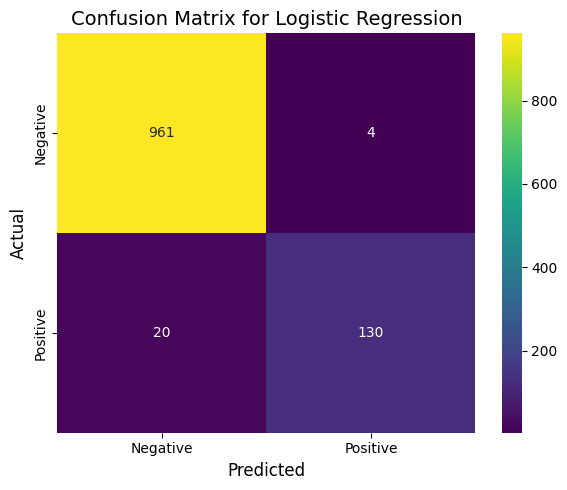

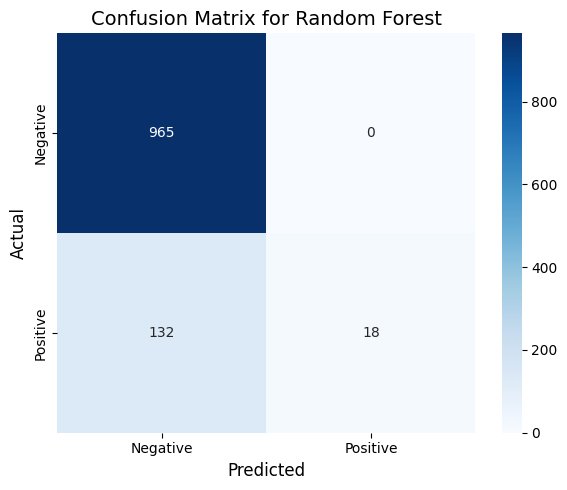

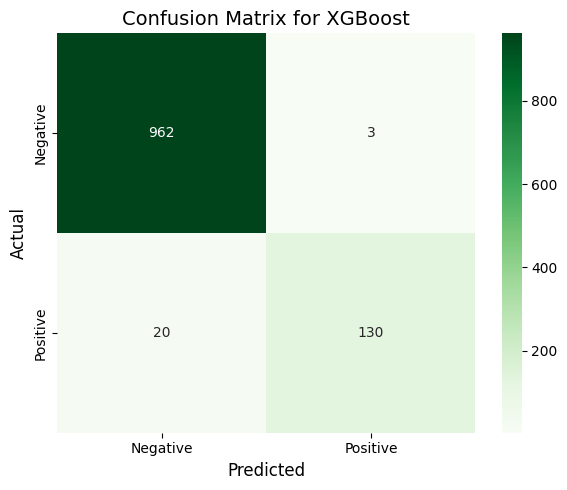

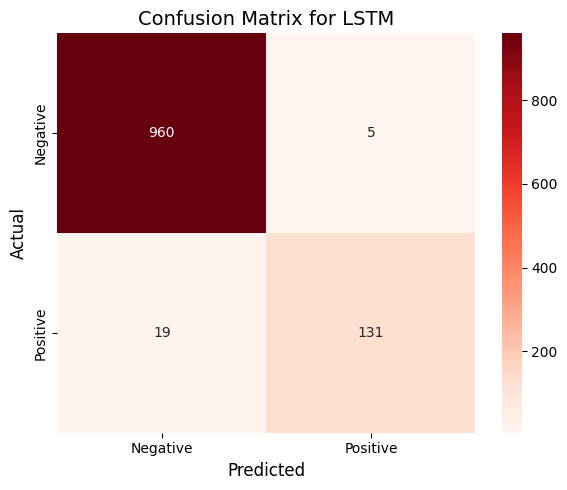

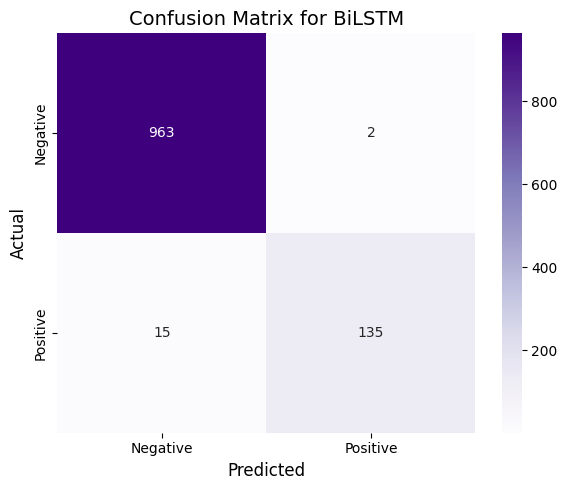

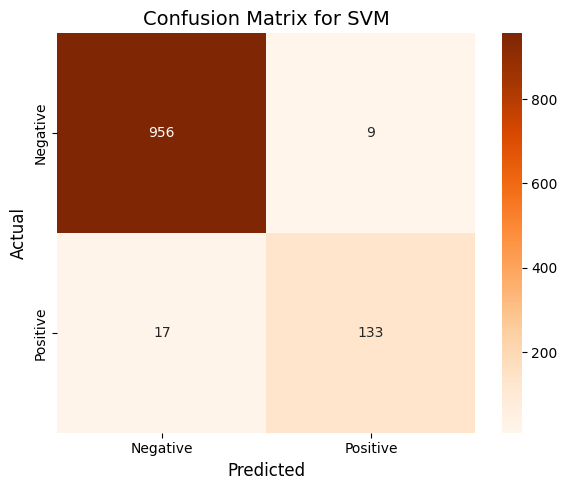

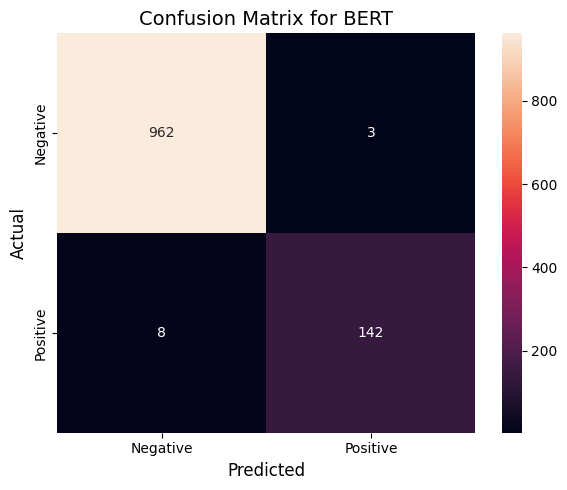

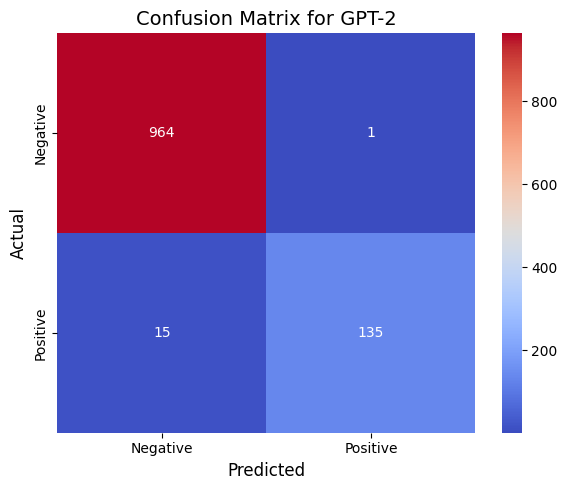

In [47]:
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression", "viridis")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest", "Blues")
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost", "Greens")
plot_confusion_matrix(y_test, y_pred_lstm, "LSTM", "Reds")
plot_confusion_matrix(y_test, y_pred_bilstm, "BiLSTM", "Purples")
plot_confusion_matrix(y_test, y_pred_svm, "SVM", "Oranges")
plot_confusion_matrix(y_test, y_pred_bibert, "BERT", "rocket")
plot_confusion_matrix(y_test, predictions, "GPT-2", "coolwarm")

In [48]:
def display_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {model_name}:")
    print(cm)
    print("-" * 40)

display_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")
display_confusion_matrix(y_test, y_pred_rf, "Random Forest")
display_confusion_matrix(y_test, y_pred_xgb, "XGBoost")
display_confusion_matrix(y_test, y_pred_lstm, "LSTM")
display_confusion_matrix(y_test, y_pred_bilstm, "BiLSTM")
display_confusion_matrix(y_test, y_pred_svm, "SVM")
display_confusion_matrix(y_test, predictions, "GPT-2")
display_confusion_matrix(y_test, y_pred_bibert, "BERT")

Confusion Matrix for Logistic Regression:
[[961   4]
 [ 20 130]]
----------------------------------------
Confusion Matrix for Random Forest:
[[965   0]
 [132  18]]
----------------------------------------
Confusion Matrix for XGBoost:
[[962   3]
 [ 20 130]]
----------------------------------------
Confusion Matrix for LSTM:
[[960   5]
 [ 19 131]]
----------------------------------------
Confusion Matrix for BiLSTM:
[[963   2]
 [ 15 135]]
----------------------------------------
Confusion Matrix for SVM:
[[956   9]
 [ 17 133]]
----------------------------------------
Confusion Matrix for GPT-2:
[[964   1]
 [ 15 135]]
----------------------------------------
Confusion Matrix for BERT:
[[962   3]
 [  8 142]]
----------------------------------------


### 3. ROC Curves

ROC curves for all models on the same axes. Higher AUC indicates better discrimination between spam and ham across thresholds.

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


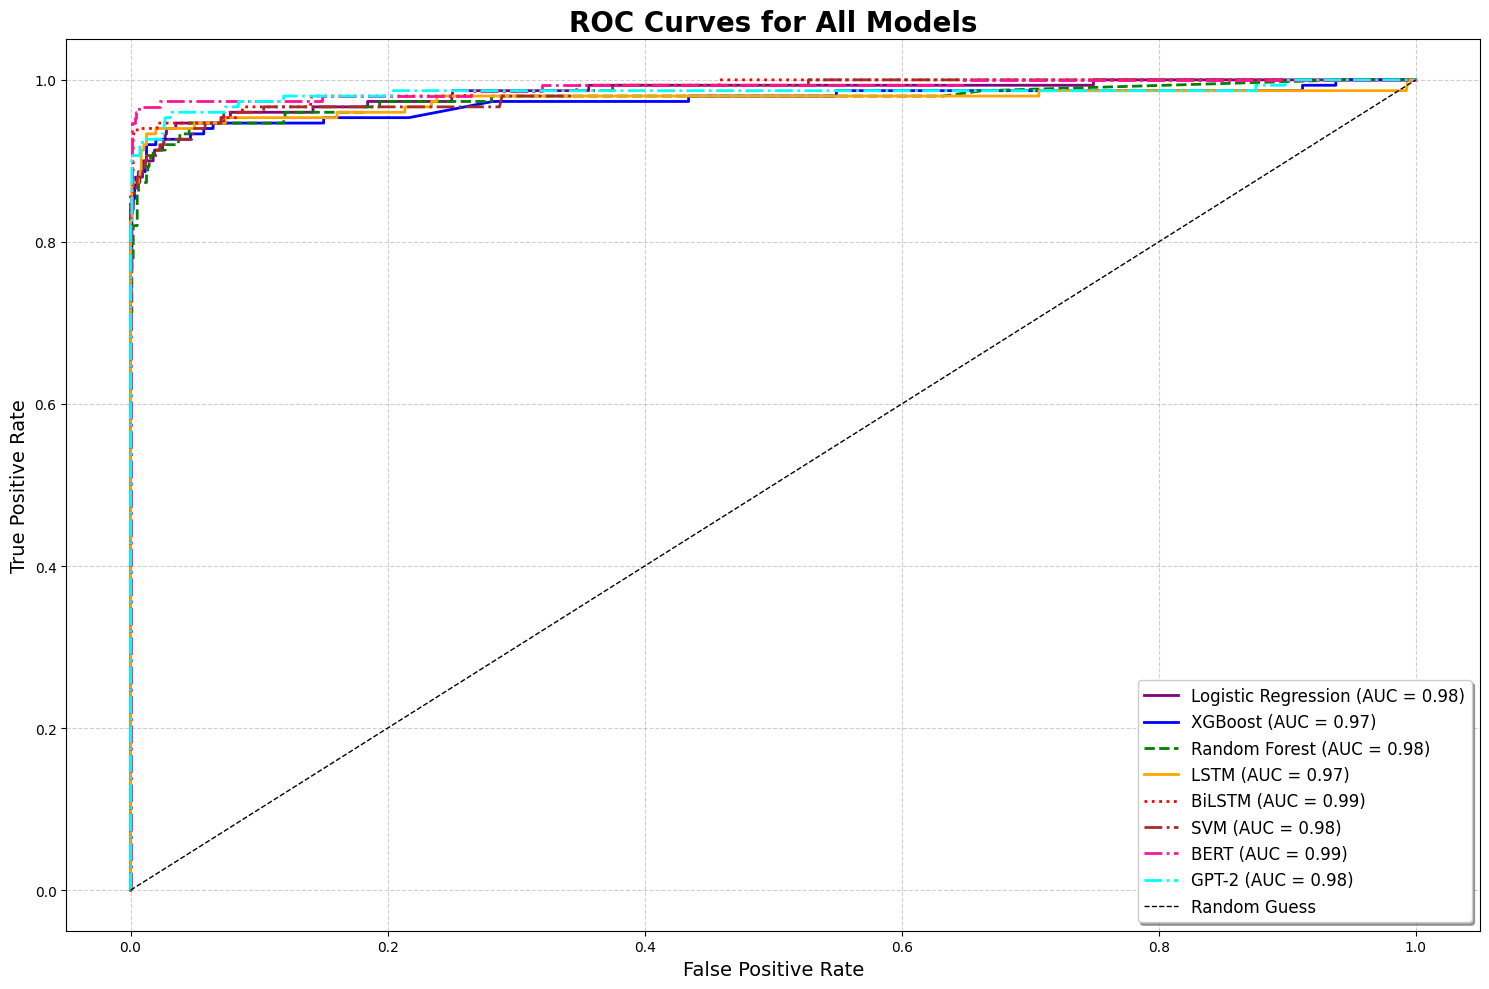

In [49]:
plt.figure(figsize=(15, 10))

# Logistic Regression ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, best_lr.predict_proba(X_test_vec)[:, 1])
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression (AUC = {:.2f})".format(auc(fpr_lr, tpr_lr)),
         linestyle="-", linewidth=2, color="purple")

# XGBoost ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = {:.2f})".format(auc(fpr_xgb, tpr_xgb)),
         linestyle="-", linewidth=2, color="blue")

# Random Forest ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test_vec)[:, 1])
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = {:.2f})".format(auc(fpr_rf, tpr_rf)),
         linestyle="--", linewidth=2, color="green")

# LSTM ROC Curve
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, lstm_model.predict(X_test_pad).flatten())
plt.plot(fpr_lstm, tpr_lstm, label="LSTM (AUC = {:.2f})".format(auc(fpr_lstm, tpr_lstm)),
         linestyle="solid", linewidth=2, color="orange")

# BiLSTM ROC Curve
fpr_bilstm, tpr_bilstm, _ = roc_curve(y_test, bi_lstm_model.predict(X_test_pad).flatten())
plt.plot(fpr_bilstm, tpr_bilstm, label="BiLSTM (AUC = {:.2f})".format(auc(fpr_bilstm, tpr_bilstm)),
         linestyle=":", linewidth=2, color="red")

# SVM ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, best_svm.decision_function(X_test_vec))
plt.plot(fpr_svm, tpr_svm, label="SVM (AUC = {:.2f})".format(auc(fpr_svm, tpr_svm)),
         linestyle="dashdot", linewidth=2, color="brown")

# Add BERT ROC Curve
fpr_bert, tpr_bert, _ = roc_curve(y_test, y_prob_bibert)
plt.plot(fpr_bert, tpr_bert, label="BERT (AUC = {:.2f})".format(auc(fpr_bert, tpr_bert)),
         linestyle="-.", linewidth=2, color="deeppink")

# GPT-2 ROC Curve
fpr_gpt2, tpr_gpt2, _ = roc_curve(y_test, y_prob_gpt2)
plt.plot(fpr_gpt2, tpr_gpt2, label="GPT-2 (AUC = {:.2f})".format(auc(fpr_gpt2, tpr_gpt2)),
        linestyle="-.", linewidth=2, color="cyan")

# Random Guess Line
plt.plot([0, 1], [0, 1], "k--", label="Random Guess", linewidth=1)


plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curves for All Models", fontsize=20, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)

plt.legend(loc="lower right", fontsize=12,frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 4. Precision-Recall Curves

Precision-Recall curves are especially informative under class imbalance. PR-AUC measures model quality independently of threshold choice.

### a. Precision Recall plot function

In [50]:
def plot_precision_recall_curve(y_true, y_prob, model_name, color):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    auc_score = auc(recall, precision)  # Area Under Curve
    plt.plot(recall, precision, label=f"{model_name} (AUC = {auc_score:.2f})", color=color, linewidth=2)

#### b. Precision-Recall for GPT-2 (batch inference)

In [51]:
def compute_precision_recall_gpt(y_true, tokenizer, texts, model, device, batch_size=16, max_len=128):
    """
    Computes the precision-recall curve for a GPT-based model.

    Parameters:
        y_true (pd.Series or np.ndarray): Ground truth labels (1D array-like).
        tokenizer (PreTrainedTokenizer): Tokenizer for the GPT model.
        texts (pd.Series or List[str]): Test text data.
        model (torch.nn.Module): The GPT-based model.
        device (torch.device): Device to run the computation on.
        batch_size (int): Number of samples per batch.
        max_len (int): Maximum sequence length for tokenization.

    Returns:
        precision (np.ndarray): Precision values for different thresholds.
        recall (np.ndarray): Recall values for different thresholds.
    """
    model.eval()

    # Convert inputs to the correct format
    if isinstance(y_true, pd.Series):  # Convert pandas Series to NumPy array
        y_true = y_true.to_numpy()
    if isinstance(texts, pd.Series):  # Convert pandas Series to a list
        texts = texts.tolist()

    y_true_tensor = torch.tensor(y_true, dtype=torch.long).to(device)

    # Initialize list for probabilities
    probs = []

    # Batch processing
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]

            # Tokenize the batch
            encodings = tokenizer(
                batch_texts, truncation=True, padding=True, max_length=max_len, return_tensors="pt"
            )

            input_ids = encodings["input_ids"].to(device)
            attention_mask = encodings["attention_mask"].to(device)

            # Run the model and collect logits
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            # Softmax to get probabilities for the positive class
            batch_probs = torch.softmax(logits, dim=1).cpu().numpy()[:, 1]
            probs.extend(batch_probs)

    # Convert probabilities to NumPy array
    probs = np.array(probs)


    precision, recall, _ = precision_recall_curve(y_true, probs)

    return precision, recall

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


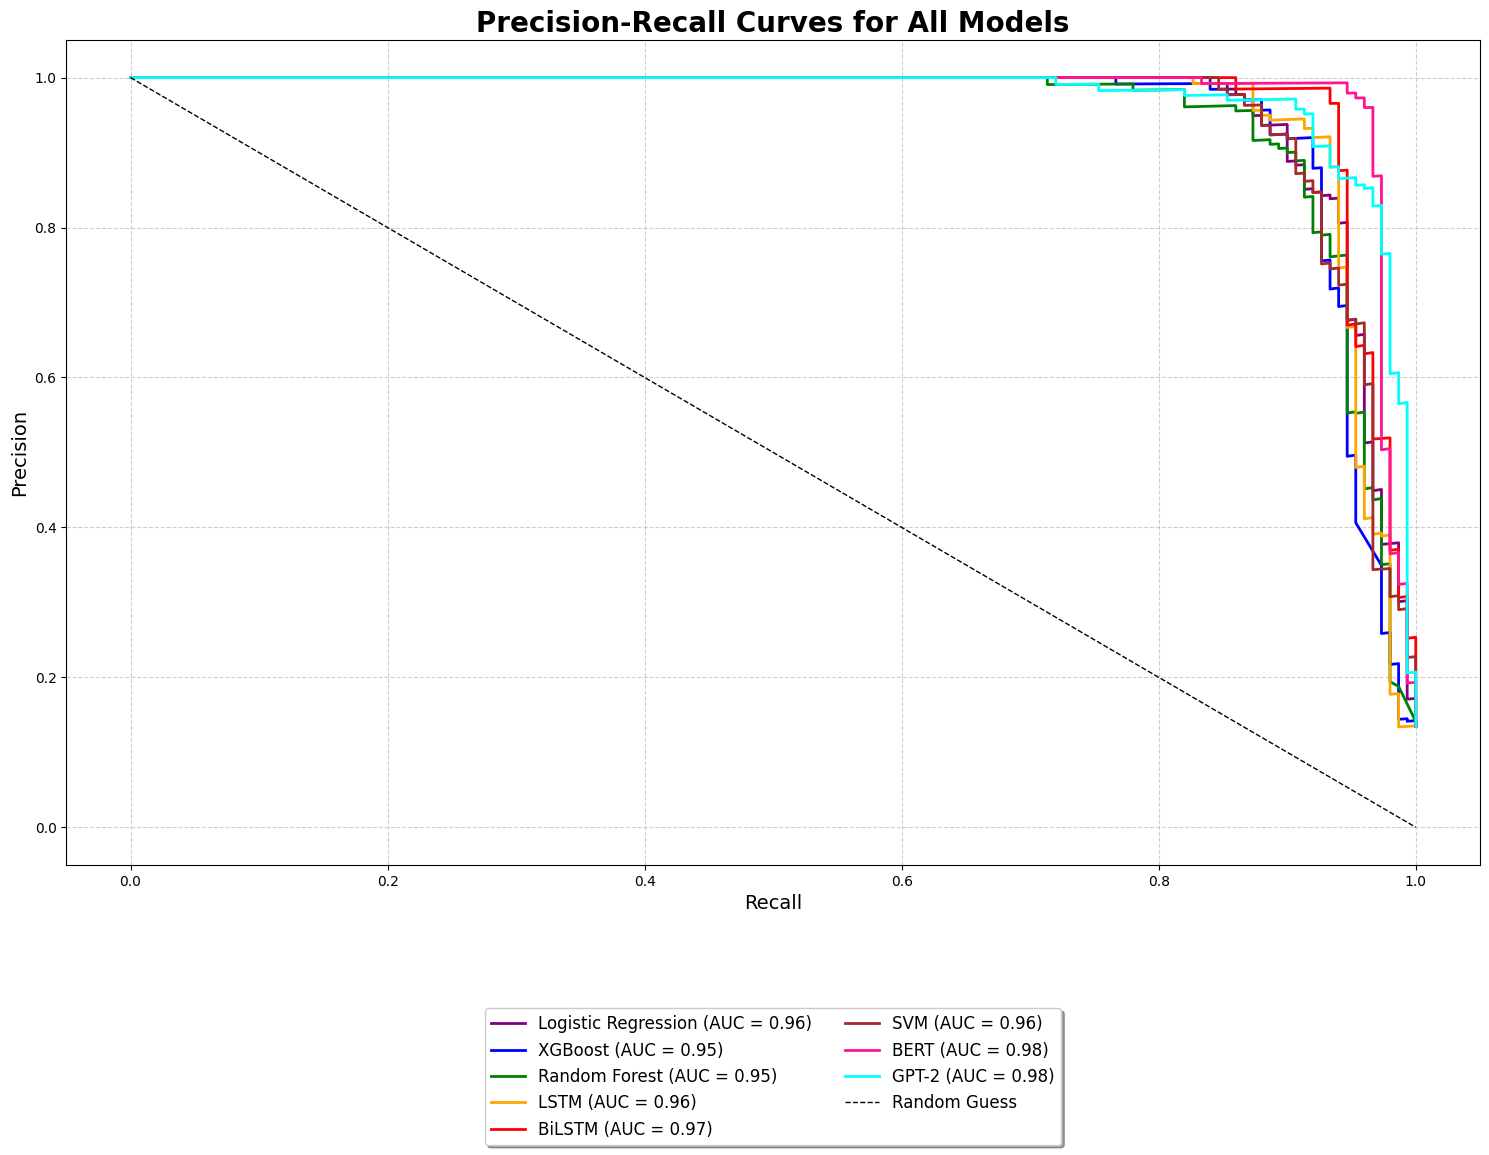

In [52]:
plt.figure(figsize=(15, 12))

# Logistic Regression Precision-Recall Curve
precision_lr, recall_lr, _ = precision_recall_curve(y_test, best_lr.predict_proba(X_test_vec)[:, 1])
plt.plot(recall_lr, precision_lr, label="Logistic Regression (AUC = {:.2f})".format(auc(recall_lr, precision_lr)),
         color="purple", linewidth=2)

# XGBoost Precision-Recall Curve
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.plot(recall_xgb, precision_xgb, label="XGBoost (AUC = {:.2f})".format(auc(recall_xgb, precision_xgb)),
         color="blue", linewidth=2)

# Random Forest Precision-Recall Curve
precision_rf, recall_rf, _ = precision_recall_curve(y_test, best_rf.predict_proba(X_test_vec)[:, 1])
plt.plot(recall_rf, precision_rf, label="Random Forest (AUC = {:.2f})".format(auc(recall_rf, precision_rf)),
         color="green", linewidth=2)

# LSTM Precision-Recall Curve
precision_lstm, recall_lstm, _ = precision_recall_curve(y_test, lstm_model.predict(X_test_pad).flatten())
plt.plot(recall_lstm, precision_lstm, label="LSTM (AUC = {:.2f})".format(auc(recall_lstm, precision_lstm)),
         color="orange", linewidth=2)

# BiLSTM Precision-Recall Curve
precision_bilstm, recall_bilstm, _ = precision_recall_curve(y_test, bi_lstm_model.predict(X_test_pad).flatten())
plt.plot(recall_bilstm, precision_bilstm, label="BiLSTM (AUC = {:.2f})".format(auc(recall_bilstm, precision_bilstm)),
         color="red", linewidth=2)

# SVM Precision-Recall Curve
precision_svm, recall_svm, _ = precision_recall_curve(y_test, best_svm.predict_proba(X_test_vec)[:, 1])
plt.plot(recall_svm, precision_svm, label="SVM (AUC = {:.2f})".format(auc(recall_svm, precision_svm)),
         color="brown", linewidth=2)

# Plot Precision-Recall curve for BERT
plot_precision_recall_curve(y_test, y_prob_bibert, "BERT", "deeppink")


# GPT Precision-Recall Curve
precision_gpt, recall_gpt = compute_precision_recall_gpt(
    y_test, tokenizer, X_test_text, model, device, batch_size=16, max_len=128
)
plt.plot(recall_gpt, precision_gpt, label="GPT-2 (AUC = {:.2f})".format(auc(recall_gpt, precision_gpt)),
         color="cyan", linewidth=2)

# Random Guess Line (Precision = Recall)
plt.plot([0, 1], [1, 0], 'k--', label="Random Guess", linewidth=1)

plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.title("Precision-Recall Curves for All Models", fontsize=20, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)

plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), fontsize=12, ncol=2, shadow=True)

plt.tight_layout()
plt.show()

---
## Part 2 : Sentiment Enrichment Pipeline

With spam classification complete, the best-performing model (BiLSTM) is combined with **VADER** to enrich the full dataset. Each message receives two annotations:

- `spam_prediction`: *spam* or *ham* (BiLSTM)
- `sentiment_label`: *Positive*, *Neutral*, or *Negative* (VADER compound score)

This dual-signal view supports downstream analysis such as: *Are spam messages more likely to use positive/urgent language?*

### Step 1 — Vectorization

A `CountVectorizer` is used here (instead of TF-IDF) to represent the test set in token-count space for the BiLSTM inference pipeline.

In [53]:
vectorizer = CountVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

### Step 2 — Initialise VADER and BiLSTM

VADER computes a compound score in [-1, 1]: above 0.1 = Positive, below -0.1 = Negative, otherwise Neutral. The BiLSTM model (`best_model`) handles spam/ham predictions.

In [54]:
analyzer = SentimentIntensityAnalyzer()
best_model = bi_lstm_model

### Step 3 — Tokenize and pad sequences

A fresh Keras `Tokenizer` is fitted on the full dataset (not just the training split) so that the BiLSTM can process all 5,572 messages during the enrichment pass.

In [55]:
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(data['clean_text'])
X_test_seq = tokenizer.texts_to_sequences(data['clean_text'])
X_test_pad = pad_sequences(X_test_seq, padding='post', maxlen=max_len)

### Step 4 — Create output columns

In [56]:
data['sentiment_label'] = None
data['vader_score'] = None
data['spam_prediction'] = None

Data is processed in batches of 128 messages. For each message, BiLSTM predicts spam/ham and VADER computes the compound sentiment score.

In [57]:
batch_size = 128
num_batches = len(data) // batch_size + 1

for batch_idx in range(num_batches):
    start_idx  = batch_idx * batch_size
    end_idx    = min((batch_idx + 1) * batch_size, len(data))
    batch_data = data.iloc[start_idx:end_idx]

    for idx, row in batch_data.iterrows():
        clean_txt = row['clean_text']

        # BiLSTM spam prediction
        seq        = tokenizer.texts_to_sequences([clean_txt])
        seq_padded = pad_sequences(seq, padding='post', maxlen=max_len)
        spam_pred  = int((best_model.predict(seq_padded, verbose=0) > 0.5).astype(int))
        data.at[idx, 'spam_prediction'] = 'spam' if spam_pred == 1 else 'ham'

        # VADER sentiment
        scores   = analyzer.polarity_scores(row['text'])
        compound = scores['compound']
        data.at[idx, 'vader_score'] = compound
        if compound > 0.1:
            data.at[idx, 'sentiment_label'] = 'Positive'
        elif compound < -0.1:
            data.at[idx, 'sentiment_label'] = 'Negative'
        else:
            data.at[idx, 'sentiment_label'] = 'Neutral'

print(f"Pipeline complete. Processed {len(data):,} messages.")
data[['text','spam_prediction','vader_score','sentiment_label']].head(10)


/tmp/ipykernel_2799/2505188001.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  spam_pred  = int((best_model.predict(seq_padded, verbose=0) > 0.5).astype(int))


Pipeline complete. Processed 5,572 messages.


,text,spam_prediction,vader_score,sentiment_label
0,"Go until jurong point, crazy.. Available only ...",ham,0.4019,Positive
1,Ok lar... Joking wif u oni...,ham,0.4767,Positive
2,Free entry in 2 a wkly comp to win FA Cup fina...,ham,0.7964,Positive
3,U dun say so early hor... U c already then say...,ham,0.0,Neutral
4,"Nah I don't think he goes to usf, he lives aro...",ham,-0.1027,Negative
5,FreeMsg Hey there darling it's been 3 week's n...,ham,0.8395,Positive
6,Even my brother is not like to speak with me. ...,ham,0.4749,Positive
7,As per your request 'Melle Melle (Oru Minnamin...,ham,0.4767,Positive
8,WINNER!! As a valued network customer you have...,ham,0.9461,Positive
9,Had your mobile 11 months or more? U R entitle...,ham,0.8747,Positive


### Step 5 — Save enriched dataset

In [58]:
from google.colab import files as colab_files

output_path = "/content/updated_bilstm_spam_dataset.csv"
data.to_csv(output_path, index=False)
print(f"Saved enriched dataset: {output_path}")
print(f"Columns: {list(data.columns)}")

# Download the file directly to your machine
colab_files.download(output_path)


Saved enriched dataset: /content/updated_bilstm_spam_dataset.csv
Columns: ['label', 'text', 'clean_text', 'sentiment_label', 'vader_score', 'spam_prediction']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Conclusion

This notebook benchmarked eight spam-detection models across three paradigms. Summary:

| Model | Paradigm | Key strength |
|---|---|---|
| Logistic Regression | Classical ML | Fast, interpretable, strong TF-IDF baseline |
| SVM | Classical ML | Strong linear boundary on sparse features |
| Random Forest | Classical ML | Robust to noise via ensemble averaging |
| XGBoost | Classical ML | Best classical model; captures non-linear patterns |
| LSTM | Deep Learning | Sequential context; outperforms classical ML on recall |
| BiLSTM | Deep Learning | Best deep learning model; bidirectional context improves recall |
| BERT | Transformer | Rich contextual embeddings; high precision on balanced data |
| GPT-2 | Transformer | Largest model; competitive but expensive for this task |

**Phase 2** showed that pairing BiLSTM predictions with VADER sentiment scores produces actionable signal, e.g. quantifying whether spam messages disproportionately use positive/urgent language.

**Possible next steps:**
- Threshold tuning to maximise spam recall at a controlled false-positive rate
- Evaluation on more recent corpora (email datasets post-2020)
- Lightweight distilled models (DistilBERT, TinyBERT) for production deployment
- Streamlit dashboard for interactive spam + sentiment prediction


## _That's all :)_